In [1]:
###################################################
import emcee
import numpy as np
import scipy

from astropy.io import fits
from astropy.table import Table
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from functools import partial
import time
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyccl as ccl
import clevar
import numpy as np
from astropy.table import Table
import clmm
from clevar.catalog import ClCatalog, MemCatalog
from clevar.match_metrics import recovery
import matplotlib.pyplot as plt
from clevar.match import MembershipMatch
from clevar.match_metrics import distances
from clevar.match_metrics import scaling
from clevar.match import ProximityMatch
from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf
###################################################

## Selection

### Catalogs

In [2]:
matching_folder = '/sps/lsst/groups/clusters/redmapper_validation_project/cosmoDC2_v1.1.4/extragal/after_matching/v0/'

t_red = Table.read(f"{matching_folder}/c1.fits")
display(t_red)
t_halo = Table.read(f"{matching_folder}/c2.fits")
display(t_halo)

id,ra,dec,z,mass,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_self,mt_frac_other,mt_cross
,,,,,"deg,deg",,,,,,,
bytes11,float64,float64,float32,float32,SkyCoord,bytes13,bytes13,bytes147,bytes147,float64,float64,bytes13
10,52.520436430812914,-25.717996124671657,0.5135129,190.70665,"52.520436430812914,-25.717996124671657",1162500021323,1162500021323,"417800021323,1162500021323,80500021323,711400021315,1361100021315,205900021323,665600021315,922700021315","417800021323,1162500021323,80500021323,1361100021315,205900021323,665600021315,922700021315,711400021315",0.4155844155844156,0.30094043887147337,1162500021323
18,56.920376528125075,-27.20434071042304,0.5712697,179.12813,"56.920376528125075,-27.20434071042304",549500032315,549500032315,549500032315,549500032315,0.9,0.35064935064935066,549500032315
24,56.99849698116052,-26.7172081871169,1.040338,124.02715,"56.99849698116052,-26.7172081871169",2554900032241,2554900032241,"1212700032259,3011300032241,2554900032241","1212700032259,3011300032241,2554900032241",0.8951048951048951,0.28444444444444444,2554900032241
30,58.56362402841767,-27.429961828331713,0.63518524,167.33603,"58.56362402841767,-27.429961828331713",1275900032300,1275900032300,"1275900032300,6600032300","1275900032300,6600032300",0.96875,0.2767857142857143,1275900032300
71,58.35519782866568,-26.867687128773035,0.44230303,111.9147,"58.35519782866568,-26.867687128773035",564000032338,564000032338,"778100032338,731900032338,243000032347,564000032338,359200032338,161400032338","731900032338,778100032338,243000032347,564000032338,359200032338,161400032338",0.4689655172413793,0.2518518518518518,564000032338
73,57.76575707007693,-28.119101936484828,0.46697217,104.439766,"57.76575707007693,-28.119101936484828",459400032338,459400032338,"2200032331,459400032338,980800032331","2200032331,459400032338,980800032331",0.8449612403100775,0.2780612244897959,459400032338
109,58.509466974185045,-26.989676182075844,0.4413634,103.49396,"58.509466974185045,-26.989676182075844",156700032338,156700032338,"433200032355,156700032338","433200032355,156700032338",0.9166666666666666,0.28672985781990523,156700032338
116,54.494027152041674,-27.896589555863095,1.0629631,76.85877,"54.494027152041674,-27.896589555863095",3080200031235,3080200031235,"3080200031235,2468800031230","3080200031235,2468800031230",0.8586956521739131,0.2791519434628975,3080200031235


id,ra,dec,z,mass,log_mass,m200c,log_m200c,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
,,,,,,,,"deg,deg",,,,,,,
bytes21,float64,float64,float64,float64,float64,float64,float64,SkyCoord,bytes6,bytes6,bytes31,bytes31,float64,float64,bytes6
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,"50.775875822529436,-27.112584328955446",--,--,--,--,0.0,0.0,--
2700020475,49.466814189348334,-25.960541211222015,0.04615640640258789,1.633e+13,13.2130360195722,15062094204754.93,13.177885359536557,"49.466814189348334,-25.960541211222015",--,--,--,--,0.0,0.0,--
17200020453,50.16585579512233,-25.259404686564693,0.08653247356414795,2.283e+13,13.358450109677962,20441971397588.734,13.310522776287003,"50.16585579512233,-25.259404686564693",--,--,--,--,0.0,0.0,--
19000020453,49.51865674267036,-26.131426039026245,0.09413313865661621,1.199e+13,13.078863522811979,10668658238016.902,13.028109803073287,"49.51865674267036,-26.131426039026245",--,--,--,--,0.0,0.0,--
19800020453,50.691634217578326,-26.88681304144144,0.08739697933197021,8.412e+13,13.924887877935069,71624983358738.03,13.855064534072003,"50.691634217578326,-26.88681304144144",--,--,--,--,0.0,0.0,--
32800020453,51.49405530538187,-26.309071814426567,0.08795535564422607,1.328e+13,13.123179943904667,10371945197971.832,13.015860213430779,"51.49405530538187,-26.309071814426567",--,--,--,--,0.0,0.0,--
2000020442,51.03054382968504,-25.767733992572435,0.10751283168792725,3.555e+13,13.550864347552649,31256384653340.848,13.494938742848014,"51.03054382968504,-25.767733992572435",--,--,--,--,0.0,0.0,--
32300020442,51.48013416475692,-25.825311694587846,0.10751473903656006,1.339e+13,13.126824099732831,11587427913554.93,13.063987045375406,"51.48013416475692,-25.825311694587846",--,--,--,--,0.0,0.0,--


In [3]:
import numpy as np
from astropy.table import Column

def clean_clevar_match_columns(tab):
    """
    Convert masked matching columns to plain object columns.
    For one-to-one match columns, masked entries become None.
    For multi-match columns, masked entries become empty lists.
    """

    one_to_one_cols = ["mt_cross", "mt_self", "mt_other"]
    multi_cols = ["mt_multi_self", "mt_multi_other"]

    for name in one_to_one_cols + multi_cols:
        if name not in tab.colnames:
            continue

        col = tab[name]
        mask = np.ma.getmaskarray(col)

        # Handle scalar mask=False case
        if mask.shape == ():
            mask = np.zeros(len(col), dtype=bool)

        cleaned = []

        for val, is_masked in zip(col, mask):
            if is_masked:
                cleaned.append([] if name in multi_cols else None)
            else:
                cleaned.append(val)

        tab[name] = Column(np.array(cleaned, dtype=object), name=name)

    return tab

In [4]:
cl_redmapper_tags = {'id':'cat1_id', 'mass':'cat1_richness', 'z':'cat1_z', 'ra':'cat1_ra','dec':'cat1_dec'}
halo_tags = {'id':'cat2_id', 'mass':'cat2_M200c','z':'cat2_z', 'ra':'cat2_ra','dec':'cat2_dec'}

col = t_halo['mt_cross']

t_halo['mt_cross'] = np.where(col.mask, None, col)
col = t_red['mt_cross']

t_red['mt_cross'] = np.where(col.mask, None, col)

t_red = clean_clevar_match_columns(t_red)
t_halo = clean_clevar_match_columns(t_halo)

cat_red = ClCatalog(data = t_red, name='cat_red')
cat_halo = ClCatalog(data = t_halo  , name='cat_halo')
print(type(cat_halo['mt_cross'][0]))
display(cat_halo)
display(cat_halo[cat_halo['mt_cross'] is None])
display(cat_red)

<class 'NoneType'>


id,ra,dec,z,mass,log_mass,m200c,log_m200c,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
str21,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,float64,float64,object
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,None,None,[],[],0.0,0.0,None
2700020475,49.466814189348334,-25.960541211222015,0.04615640640258789,1.633e+13,13.2130360195722,15062094204754.93,13.177885359536557,None,None,[],[],0.0,0.0,None
17200020453,50.16585579512233,-25.259404686564693,0.08653247356414795,2.283e+13,13.358450109677962,20441971397588.734,13.310522776287003,None,None,[],[],0.0,0.0,None
19000020453,49.51865674267036,-26.131426039026245,0.09413313865661621,1.199e+13,13.078863522811979,10668658238016.902,13.028109803073287,None,None,[],[],0.0,0.0,None
19800020453,50.691634217578326,-26.88681304144144,0.08739697933197021,8.412e+13,13.924887877935069,71624983358738.03,13.855064534072003,None,None,[],[],0.0,0.0,None
32800020453,51.49405530538187,-26.309071814426567,0.08795535564422607,1.328e+13,13.123179943904667,10371945197971.832,13.015860213430779,None,None,[],[],0.0,0.0,None
2000020442,51.03054382968504,-25.767733992572435,0.10751283168792725,3.555e+13,13.550864347552649,31256384653340.848,13.494938742848014,None,None,[],[],0.0,0.0,None
32300020442,51.48013416475692,-25.825311694587846,0.10751473903656006,1.339e+13,13.126824099732831,11587427913554.93,13.063987045375406,None,None,[],[],0.0,0.0,None
33300020442,50.315518939516316,-26.69559169836869,0.108817458152771,3.434e+13,13.53575955305564,29876928281239.438,13.475335944579681,47951,47951,47951,47951,0.6666666666666666,0.5,47951


id,ra,dec,z,mass,log_mass,m200c,log_m200c,SkyCoord,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_other,mt_frac_self,mt_cross
,,,,,,,,"deg,deg",,,,,,,
str21,float64,float64,float64,float64,float64,float64,float64,SkyCoord,object,object,object,object,float64,float64,object
1600020475,50.775875822529436,-27.112584328955446,0.04530489444732666,2.247e+13,13.351613892324458,18901145086557.746,13.276488115798056,"50.775875822529436,-27.112584328955446",None,None,[],[],0.0,0.0,None


id,ra,dec,z,mass,mt_self,mt_other,mt_multi_self,mt_multi_other,mt_frac_self,mt_frac_other,mt_cross
str11,float64,float64,float32,float32,object,object,object,object,float64,float64,object
10,52.520436430812914,-25.717996124671657,0.5135129,190.70665,1162500021323,1162500021323,"417800021323,1162500021323,80500021323,711400021315,1361100021315,205900021323,665600021315,922700021315","417800021323,1162500021323,80500021323,1361100021315,205900021323,665600021315,922700021315,711400021315",0.4155844155844156,0.30094043887147337,1162500021323
18,56.920376528125075,-27.20434071042304,0.5712697,179.12813,549500032315,549500032315,549500032315,549500032315,0.9,0.35064935064935066,549500032315
24,56.99849698116052,-26.7172081871169,1.040338,124.02715,2554900032241,2554900032241,"1212700032259,3011300032241,2554900032241","1212700032259,3011300032241,2554900032241",0.8951048951048951,0.28444444444444444,2554900032241
30,58.56362402841767,-27.429961828331713,0.63518524,167.33603,1275900032300,1275900032300,"1275900032300,6600032300","1275900032300,6600032300",0.96875,0.2767857142857143,1275900032300
71,58.35519782866568,-26.867687128773035,0.44230303,111.9147,564000032338,564000032338,"778100032338,731900032338,243000032347,564000032338,359200032338,161400032338","731900032338,778100032338,243000032347,564000032338,359200032338,161400032338",0.4689655172413793,0.2518518518518518,564000032338
73,57.76575707007693,-28.119101936484828,0.46697217,104.439766,459400032338,459400032338,"2200032331,459400032338,980800032331","2200032331,459400032338,980800032331",0.8449612403100775,0.2780612244897959,459400032338
109,58.509466974185045,-26.989676182075844,0.4413634,103.49396,156700032338,156700032338,"433200032355,156700032338","433200032355,156700032338",0.9166666666666666,0.28672985781990523,156700032338
116,54.494027152041674,-27.896589555863095,1.0629631,76.85877,3080200031235,3080200031235,"3080200031235,2468800031230","3080200031235,2468800031230",0.8586956521739131,0.2791519434628975,3080200031235
133,58.137368555958155,-27.199784884537003,1.037697,75.89771,2067100032241,2067100032241,"1539400032241,980000032235,2412900032235,2067100032241,1231200032230","1539400032241,980000032235,2412900032235,2067100032241,1231200032230",0.8863636363636364,0.29213483146067415,2067100032241


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# Analysis bins
# ============================================================

z_bins = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
rich_bins = np.array([20, 35, 70, 120, 200])

def mids(x):
    x = np.asarray(x, dtype=float)
    return 0.5 * (x[1:] + x[:-1])

def geom_mids(x):
    x = np.asarray(x, dtype=float)
    return np.sqrt(x[1:] * x[:-1])


# ============================================================
# Error model from your code
# ============================================================

def cp_fracUnc(Npass, Ntotal):
    if Ntotal > 0:
        if Npass > 0:
            return np.sqrt((1 / Npass) + (1 - Ntotal**2) / Ntotal**4)
        else:
            return np.sqrt(1 / Ntotal)
    else:
        return np.nan

def get_cp_pm(Npass, Ntotal, recovery, bound=True):
    f = lambda Np, Nt, rec, i: (
        rec * (1 + (-1)**i * cp_fracUnc(Np, Nt))
        if ((rec > 0) | (Nt == 0))
        else (-1)**i * np.sqrt(1 / Nt)
    )

    out = np.array([
        np.vectorize(f)(Npass, Ntotal, recovery, i)
        for i in range(2)
    ])

    if bound:
        out = np.clip(out, 0, 1)

    return out



In [6]:
from crow import completeness_models
from crow import purity_models

purity_aguena = purity_models.PurityAguena16LnProxy()
completeness_aguena = completeness_models.CompletenessAguena16()

In [7]:
def plot_purity_in_richness_panels_with_model(
    info,
    purity_model,
    ylabel,
    xlabel,
    filename,
    ylim=(0, 1.05),
):
    """
    Assumes info was built with:
        col1 = redshift
        col2 = richness

    recovery shape: [z_bin, richness_bin]
    recovery.T shape: [richness_bin, z_bin]
    """

    z_edges = np.asarray(info["edges1"], dtype=float)
    rich_edges = np.asarray(info["edges2"], dtype=float)

    recovery = np.asarray(info["recovery"], dtype=float).T
    counts = np.asarray(info["counts"], dtype=float).T
    matched = np.asarray(info["matched"], dtype=float).T


    n_rich = len(rich_edges) - 1

    fig, axs = plt.subplots(
        n_rich, 1,
        figsize=(4.0, 1.15 * n_rich),
        dpi=300,
        sharex=True,
    )

    if n_rich == 1:
        axs = [axs]

    z_model = np.linspace(z_edges[0], z_edges[-1], 300)

    for j, ax in enumerate(axs):
        color = f"C{j}"

        # Data
        ax.stairs(
            recovery[j],
            z_edges,
            color=color,
            lw=1.1,
        )


        # Model at richness-bin center
        rich_center = np.sqrt(rich_edges[j] * rich_edges[j + 1])
        log_mass_proxy = np.log10(rich_center)   # because PurityAguena16LnProxy

        p_model = purity_model.distribution(
            np.full_like(z_model, log_mass_proxy),
            z_model,
        )

        ax.plot(
            z_model,
            p_model,
            color="k",
            ls="--",
            lw=1.0,
        )

        label = rf"${rich_edges[j]:.0f} < \lambda_{{\rm cl}} < {rich_edges[j+1]:.0f}$"

        ax.text(
            0.03,
            0.12,
            label,
            transform=ax.transAxes,
            fontsize="x-small",
            bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.8),
        )

        ax.set_ylim(*ylim)
        ax.set_xlim(z_edges[0], z_edges[-1])

        ax.grid(which="major", lw=0.5, alpha=0.8)
        ax.grid(which="minor", lw=0.2, alpha=0.5)

        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.02))


    axs[-1].set_xlabel(xlabel, loc="right")
    axs[0].set_ylabel(ylabel, loc="top")

    fig.subplots_adjust(hspace=0.08)
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

    return fig, axs

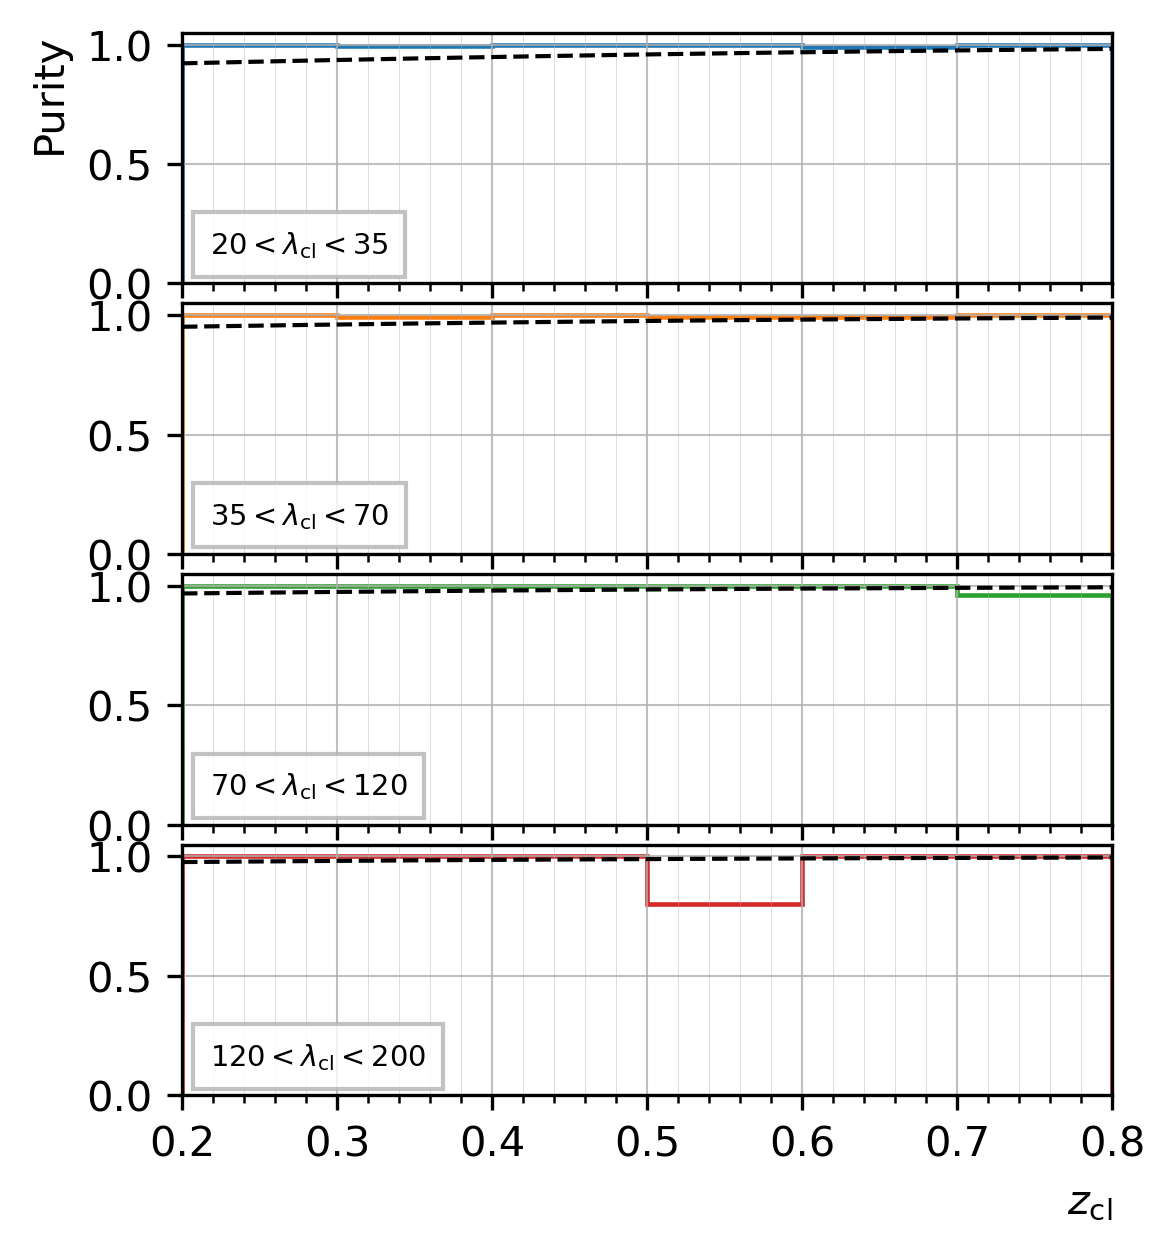

(<Figure size 1200x1380 with 4 Axes>,
 array([<Axes: ylabel='Purity'>, <Axes: >, <Axes: >,
        <Axes: xlabel='$z_{\\rm cl}$'>], dtype=object))

In [8]:
fig_tmp, ax_tmp = plt.subplots()

info_purity = r_cf.plot(
    cat_red,
    col1="z",
    col2="mass",          # richness, because redmapper mass tag maps to richness
    bins1=z_bins,
    bins2=rich_bins,
    matching_type="cross",
    ax=ax_tmp,
    add_legend=False,
)["data"]

plt.close(fig_tmp)

plot_purity_in_richness_panels_with_model(
    info_purity,
    purity_aguena,
    ylabel="Purity",
    xlabel=r"$z_{\rm cl}$",
    filename="./figures/purity_by_richness_z_with_model.png",
)

In [9]:
def plot_completeness_in_mass_panels_with_model(
    info,
    completeness_model,
    ylabel,
    xlabel,
    filename,
    ylim=(0, 1.05),
):
    """
    Assumes info was built with:
        col1 = redshift
        col2 = halo mass

    recovery shape: [z_bin, mass_bin]
    recovery.T shape: [mass_bin, z_bin]
    """

    z_edges = np.asarray(info["edges1"], dtype=float)
    mass_edges = np.asarray(info["edges2"], dtype=float)

    recovery = np.asarray(info["recovery"], dtype=float).T
    counts = np.asarray(info["counts"], dtype=float).T
    matched = np.asarray(info["matched"], dtype=float).T


    n_mass = len(mass_edges) - 1

    fig, axs = plt.subplots(
        n_mass, 1,
        figsize=(4.0, 1.15 * n_mass),
        dpi=300,
        sharex=True,
    )

    if n_mass == 1:
        axs = [axs]

    z_model = np.linspace(z_edges[0], z_edges[-1], 300)

    for j, ax in enumerate(axs):
        color = f"C{j}"

        # Data
        ax.stairs(
            recovery[j],
            z_edges,
            color=color,
            lw=1.1,
        )


        # Model at mass-bin center
        mass_center = np.sqrt(mass_edges[j] * mass_edges[j + 1])
        log_mass = np.log10(mass_center)

        c_model = completeness_model.distribution(
            np.full_like(z_model, log_mass),
            z_model,
        )

        ax.plot(
            z_model,
            c_model,
            color="k",
            ls="--",
            lw=1.0,
        )

        label = (
            rf"$10^{{{np.log10(mass_edges[j]):.1f}}}"
            rf" < M_{{200c}} < "
            rf"10^{{{np.log10(mass_edges[j+1]):.1f}}}$"
        )
        
        y_label = 0.32 if j == 0 else 0.12
        
        ax.text(
            0.03,
            y_label,
            label,
            transform=ax.transAxes,
            fontsize=6.5,
            bbox=dict(
                facecolor="white",
                edgecolor="0.8",
                alpha=0.65,
                boxstyle="round,pad=0.15",
            ),
        )

        ax.set_ylim(*ylim)
        ax.set_xlim(z_edges[0], z_edges[-1])

        ax.grid(which="major", lw=0.5, alpha=0.8)
        ax.grid(which="minor", lw=0.2, alpha=0.5)

        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.02))



    axs[-1].set_xlabel(xlabel, loc="right")
    axs[0].set_ylabel(ylabel, loc="top")

    fig.subplots_adjust(hspace=0.08)
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

    return fig, axs

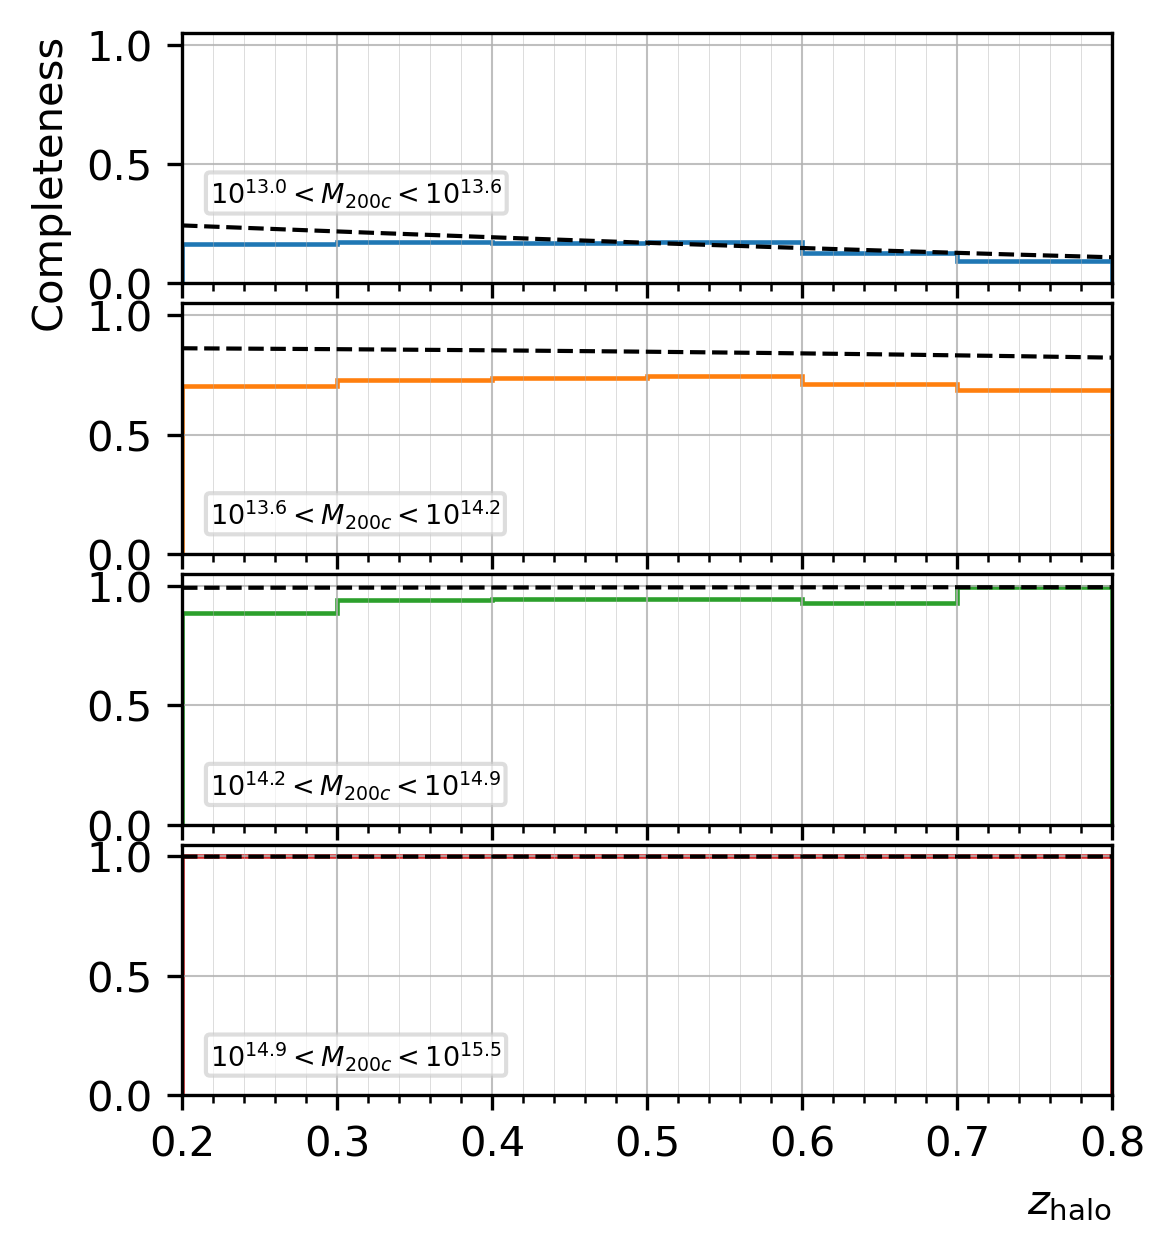

(<Figure size 1200x1380 with 4 Axes>,
 array([<Axes: ylabel='Completeness'>, <Axes: >, <Axes: >,
        <Axes: xlabel='$z_{\\rm halo}$'>], dtype=object))

In [10]:
mass_bins = np.logspace(13.0, 15.5, 5)

fig_tmp, ax_tmp = plt.subplots()

info_completeness = r_cf.plot(
    cat_halo,
    col1="z",
    col2="mass",
    bins1=z_bins,
    bins2=mass_bins,
    matching_type="cross",
    ax=ax_tmp,
    add_legend=False,
)["data"]

plt.close(fig_tmp)

plot_completeness_in_mass_panels_with_model(
    info_completeness,
    completeness_aguena,
    ylabel="Completeness",
    xlabel=r"$z_{\rm halo}$",
    filename="./figures/completeness_by_mass_z_with_model.png",
)